# Árvore de Classificação – Preferência por Transporte Público



In [1]:
# Importação de bibliotecas essenciais para o modelo
import pandas as pd                      # manipulação de dados
from sklearn.tree import DecisionTreeClassifier, plot_tree  # modelo e visualização
from sklearn.model_selection import train_test_split        # divisão em treino/teste
from sklearn.metrics import accuracy_score, classification_report  # avaliação do modelo
import matplotlib.pyplot as plt         # visualização de gráficos


In [2]:
# Leitura da base de dados CSV contendo 100 amostras
df = pd.read_csv("base_exemplo_classificacao.csv")

# Exibição das 5 primeiras linhas para verificação
df.head()


,Idade,Veiculo,Acesso_TP,Trabalha_Presencial,Renda,Prefere_TP
0,58,Sim,Sim,Nao,5512,Nao
1,32,Sim,Sim,Sim,11174,Nao
2,45,Sim,Sim,Sim,5082,Nao
3,32,Sim,Sim,Nao,5111,Nao
4,46,Nao,Sim,Sim,8424,Nao


In [3]:
# Conversão de variáveis categóricas em variáveis numéricas usando one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Veiculo', 'Acesso_TP', 'Trabalha_Presencial'], drop_first=True)

# Separação entre as variáveis independentes (X) e a variável dependente (y)
X = df_encoded.drop('Prefere_TP', axis=1)  # preditoras
y = df['Prefere_TP'].map({'Sim': 1, 'Nao': 0})  # variável alvo codificada em 0 e 1


In [4]:
# Separação dos dados em conjunto de treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # random_state garante reprodutibilidade
)


In [5]:
# Instanciação do modelo com parâmetros ajustados
clf = DecisionTreeClassifier(
    max_depth=4,               # profundidade máxima da árvore
    min_samples_split=10,      # mínimo de amostras por nó para permitir split
    criterion="gini",          # critério de impureza (padrão: gini)
    random_state=42            # reprodutibilidade
)

# Treinamento do modelo com os dados de treino
clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)

In [6]:
# Geração de previsões com os dados de teste
y_pred = clf.predict(X_test)

# Impressão da acurácia e do relatório de classificação (precisão, recall, f1-score)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n", classification_report(y_test, y_pred))


Acurácia: 0.9

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.93      0.96      0.95        28
           1       0.00      0.00      0.00         2

    accuracy                           0.90        30
   macro avg       0.47      0.48      0.47        30
weighted avg       0.87      0.90      0.88        30



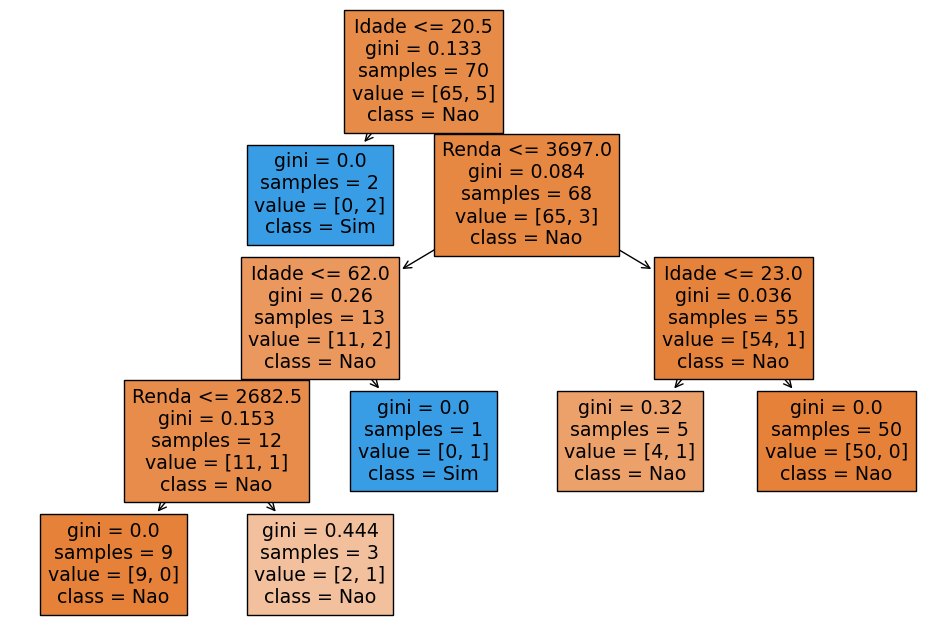

In [7]:
# Visualização gráfica da árvore de decisão treinada
plt.figure(figsize=(12, 8))  # define o tamanho da figura
plot_tree(
    clf, 
    feature_names=X.columns,        # nomes das features
    class_names=['Nao', 'Sim'],     # nomes das classes
    filled=True                     # preenche os nós com cor baseada na classe
)
plt.show()
